#Install Library

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.5 MB/s eta 0:00:00


#Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import csv
import requests
import nltk
from wordcloud import WordCloud
from io import StringIO
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from collections import Counter
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

#Import Data

In [ ]:
url= "https://raw.githubusercontent.com/ariesdav/scrape-playstore/main/data/rawipusnasdata.csv"
df = pd.read_csv(url)
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,8cf3456f-3b52-41a8-ab6c-e81fb9d1f47f,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"sebagai warga yang dengan dana minim, tapi ing...",2,0,2.1.4,2026-05-13 07:45:52,NaN,NaN,2.1.4
1,619194eb-2851-497d-ad26-62d7d07b4e39,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,hp saya android 9 mendadak sudah tidak bisa di...,1,2,2.1.2,2026-05-09 22:43:42,NaN,NaN,2.1.2
2,d636b3d0-728e-4f0f-99b7-8ab7abdba2c2,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,update terbaru 9 mei 2026 alangkah susahnya ya...,2,15,2.1.4,2026-05-09 12:23:06,Hallo Andrian! Kami mohon maaf atas ketidaknya...,2023-04-13 01:54:45,2.1.4
3,cb4da8bf-850e-423a-861e-6f323a218c0c,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Cant even log in,5,0,2.1.4,2026-05-08 13:50:34,NaN,NaN,2.1.4
4,dc185226-10e3-4d48-8a0c-2ff63f1dc232,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasinya makin lama makin jelek aja. dari y...,1,93,2.1.4,2026-05-08 12:30:46,NaN,NaN,2.1.4


In [ ]:
pd.set_option('display.max_colwidth', 100)
print(df[['content']].head(5))

                                                                                               content
0  sebagai warga yang dengan dana minim, tapi ingin tetap membaca, saya mohon sekali, agar ada peni...
1  hp saya android 9 mendadak sudah tidak bisa digunakan untuk mengakses ipusnas :( padahal digilib...
2  update terbaru 9 mei 2026 alangkah susahnya ya mau baca buku aja selalu verifikasi perangkat gag...
3                                                                                     Cant even log in
4  aplikasinya makin lama makin jelek aja. dari yg awalny sering ngelag, eror gk bisa minjem, gk bi...


#Data Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3513 entries, 0 to 3512
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              3513 non-null   object
 1   userName              3513 non-null   object
 2   userImage             3513 non-null   object
 3   content               3512 non-null   object
 4   score                 3513 non-null   int64 
 5   thumbsUpCount         3513 non-null   int64 
 6   reviewCreatedVersion  2699 non-null   object
 7   at                    3513 non-null   object
 8   replyContent          1426 non-null   object
 9   repliedAt             1426 non-null   object
 10  appVersion            2699 non-null   object
dtypes: int64(2), object(9)
memory usage: 302.0+ KB


In [ ]:
df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,1
score,0
thumbsUpCount,0
reviewCreatedVersion,814
at,0
replyContent,2087
repliedAt,2087


In [ ]:
df = df.replace('', np.nan).replace(' ', np.nan)
df = df.fillna('unknown')

In [ ]:
df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,0
at,0
replyContent,0
repliedAt,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3513 entries, 0 to 3512
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              3513 non-null   object
 1   userName              3513 non-null   object
 2   userImage             3513 non-null   object
 3   content               3513 non-null   object
 4   score                 3513 non-null   int64 
 5   thumbsUpCount         3513 non-null   int64 
 6   reviewCreatedVersion  3513 non-null   object
 7   at                    3513 non-null   object
 8   replyContent          3513 non-null   object
 9   repliedAt             3513 non-null   object
 10  appVersion            3513 non-null   object
dtypes: int64(2), object(9)
memory usage: 302.0+ KB


#Data Preprocssing

In [ ]:
#case folding
def caseFoldingText(text):
  return str(text).lower()

df['case_folding'] = df['content'].apply(caseFoldingText)
df[['content','case_folding']].head()

,content,case_folding
0,"sebagai warga yang dengan dana minim, tapi ingin tetap membaca, saya mohon sekali, agar ada peni...","sebagai warga yang dengan dana minim, tapi ingin tetap membaca, saya mohon sekali, agar ada peni..."
1,hp saya android 9 mendadak sudah tidak bisa digunakan untuk mengakses ipusnas :( padahal digilib...,hp saya android 9 mendadak sudah tidak bisa digunakan untuk mengakses ipusnas :( padahal digilib...
2,update terbaru 9 mei 2026 alangkah susahnya ya mau baca buku aja selalu verifikasi perangkat gag...,update terbaru 9 mei 2026 alangkah susahnya ya mau baca buku aja selalu verifikasi perangkat gag...
3,Cant even log in,cant even log in
4,"aplikasinya makin lama makin jelek aja. dari yg awalny sering ngelag, eror gk bisa minjem, gk bi...","aplikasinya makin lama makin jelek aja. dari yg awalny sering ngelag, eror gk bisa minjem, gk bi..."


In [ ]:
#cleaning (regex)
def cleaningText(text):
  text = str(text)
  text = re.sub(r'@\w+', '', text) #hapus mention
  text = re.sub(r'#\w+', '', text) #hapus hashtag
  text = re.sub(r'http\S+', '', text) #hapus URL
  text = re.sub(r'\d+', '', text) #hapus angka
  text = re.sub(r'[^\w\s]', '', text) #hapus tanda baca
  text = re.sub(r'[^\x00-\x7f]', '', text) #hapus emoji
  text = re.sub(r'\s+', ' ', text).strip() #merapihkan spaasi
  return text

df['cleaning']=df['case_folding'].apply(cleaningText)
df[['case_folding','cleaning']].head()

,case_folding,cleaning
0,"sebagai warga yang dengan dana minim, tapi ingin tetap membaca, saya mohon sekali, agar ada peni...",sebagai warga yang dengan dana minim tapi ingin tetap membaca saya mohon sekali agar ada peningk...
1,hp saya android 9 mendadak sudah tidak bisa digunakan untuk mengakses ipusnas :( padahal digilib...,hp saya android mendadak sudah tidak bisa digunakan untuk mengakses ipusnas padahal digilib lain...
2,update terbaru 9 mei 2026 alangkah susahnya ya mau baca buku aja selalu verifikasi perangkat gag...,update terbaru mei alangkah susahnya ya mau baca buku aja selalu verifikasi perangkat gagal susa...
3,cant even log in,cant even log in
4,"aplikasinya makin lama makin jelek aja. dari yg awalny sering ngelag, eror gk bisa minjem, gk bi...",aplikasinya makin lama makin jelek aja dari yg awalny sering ngelag eror gk bisa minjem gk bisa ...


In [ ]:
#slang replacement
slangWords_df = pd.read_csv('https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv')
slangFormal = dict(zip(slangWords_df['slang'], slangWords_df['formal']))

def replaceSlang(text):
  words = text.split()
  replacedWords = [slangFormal.get(word, word) for word in words]
  return ' '.join(replacedWords)

df['slang'] = df['cleaning'].apply(replaceSlang)
df[['cleaning','slang']].head()

,cleaning,slang
0,sebagai warga yang dengan dana minim tapi ingin tetap membaca saya mohon sekali agar ada peningk...,sebagai warga yang dengan dana minim tapi ingin tetap membaca saya mohon sekali agar ada peningk...
1,hp saya android mendadak sudah tidak bisa digunakan untuk mengakses ipusnas padahal digilib lain...,hp saya android mendadak sudah tidak bisa digunakan untuk mengakses ipusnas padahal digilib lain...
2,update terbaru mei alangkah susahnya ya mau baca buku aja selalu verifikasi perangkat gagal susa...,update terbaru mei alangkah susahnya ya mau baca buku saja selalu verifikasi perangkat gagal sus...
3,cant even log in,cant even log ini
4,aplikasinya makin lama makin jelek aja dari yg awalny sering ngelag eror gk bisa minjem gk bisa ...,aplikasinya makin lama makin jelek saja dari yang awalny sering ngelag eror enggak bisa minjem e...


In [ ]:
#tokenizing
def tokenizingText(text):
  return word_tokenize(text)

df['tokenizing'] = df['slang'].apply(tokenizingText)
df[['slang','tokenizing']].head()

,slang,tokenizing
0,sebagai warga yang dengan dana minim tapi ingin tetap membaca saya mohon sekali agar ada peningk...,"[sebagai, warga, yang, dengan, dana, minim, tapi, ingin, tetap, membaca, saya, mohon, sekali, ag..."
1,hp saya android mendadak sudah tidak bisa digunakan untuk mengakses ipusnas padahal digilib lain...,"[hp, saya, android, mendadak, sudah, tidak, bisa, digunakan, untuk, mengakses, ipusnas, padahal,..."
2,update terbaru mei alangkah susahnya ya mau baca buku saja selalu verifikasi perangkat gagal sus...,"[update, terbaru, mei, alangkah, susahnya, ya, mau, baca, buku, saja, selalu, verifikasi, perang..."
3,cant even log ini,"[cant, even, log, ini]"
4,aplikasinya makin lama makin jelek saja dari yang awalny sering ngelag eror enggak bisa minjem e...,"[aplikasinya, makin, lama, makin, jelek, saja, dari, yang, awalny, sering, ngelag, eror, enggak,..."


In [ ]:
#filtering (stopwords)
stopwordsIndo = set(stopwords.words('indonesian'))
stopwordsEng = set(stopwords.words('english'))
combinedStopwords = stopwordsIndo.union(stopwordsEng)
combinedStopwords.update({'btw','wkwk','hehe','haha','loh','yah','kok','gue','lu'})
negationWords = {'tidak','tak','bukan','ga','gak','nggak','enggak','belum'}
combinedStopwords = combinedStopwords - negationWords
def filteringText(tokens):
  return [word for word in tokens if word not in combinedStopwords]

df['filtered']=df['tokenizing'].apply(filteringText)
df[['tokenizing','filtered']].head()

,tokenizing,filtered
0,"[sebagai, warga, yang, dengan, dana, minim, tapi, ingin, tetap, membaca, saya, mohon, sekali, ag...","[warga, dana, minim, membaca, mohon, peningkatan, aplikasi, jujur, tidak, nyaman, baca, tidak, a..."
1,"[hp, saya, android, mendadak, sudah, tidak, bisa, digunakan, untuk, mengakses, ipusnas, padahal,...","[hp, android, mendadak, tidak, mengakses, ipusnas, digilib, sedih, banget, pengin, baca, gratis,..."
2,"[update, terbaru, mei, alangkah, susahnya, ya, mau, baca, buku, saja, selalu, verifikasi, perang...","[update, terbaru, mei, alangkah, susahnya, ya, baca, buku, verifikasi, perangkat, gagal, susahny..."
3,"[cant, even, log, ini]","[cant, even, log]"
4,"[aplikasinya, makin, lama, makin, jelek, saja, dari, yang, awalny, sering, ngelag, eror, enggak,...","[aplikasinya, jelek, awalny, ngelag, eror, enggak, minjem, enggak, dibuka, aplikasinya, buka, ap..."


In [ ]:
#stemming
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# exception: kata yang kalau distem penuh dapat mengubah makna
stemExceptions = {
    "diperbaiki": "masalah",
    "memperbaiki": "masalah",
    "diperbaikinya": "masalah",
    "perbaikan": "masalah",
    "dibenerin": "masalah",
    "dibetulin": "masalah",
}

def stemmingText(tokens):
  result = []
  for w in tokens:
    wl = w.lower()
    if wl in stemExceptions:
      result.append(stemExceptions[wl])
    else:
      result.append(stemmer.stem(w))
  return result

df['stemmed'] = df['filtered'].apply(stemmingText)
df[['filtered','stemmed']].head()

,filtered,stemmed
0,"[warga, dana, minim, membaca, mohon, peningkatan, aplikasi, jujur, tidak, nyaman, baca, tidak, a...","[warga, dana, minim, baca, mohon, tingkat, aplikasi, jujur, tidak, nyaman, baca, tidak, aplikasi..."
1,"[hp, android, mendadak, tidak, mengakses, ipusnas, digilib, sedih, banget, pengin, baca, gratis,...","[hp, android, dadak, tidak, akses, ipusnas, digilib, sedih, banget, pengin, baca, gratis, legal,..."
2,"[update, terbaru, mei, alangkah, susahnya, ya, baca, buku, verifikasi, perangkat, gagal, susahny...","[update, baru, mei, alangkah, susah, ya, baca, buku, verifikasi, perangkat, gagal, susah, negeri..."
3,"[cant, even, log]","[cant, even, log]"
4,"[aplikasinya, jelek, awalny, ngelag, eror, enggak, minjem, enggak, dibuka, aplikasinya, buka, ap...","[aplikasi, jelek, awalny, ngelag, eror, enggak, minjem, enggak, buka, aplikasi, buka, aplikasiny..."


In [ ]:
#merge text
def toSentence(tokens):
    return " ".join(tokens)

df['final_text'] = df['stemmed'].apply(toSentence)
df[['content','final_text']].head()

,content,final_text
0,"sebagai warga yang dengan dana minim, tapi ingin tetap membaca, saya mohon sekali, agar ada peni...",warga dana minim baca mohon tingkat aplikasi jujur tidak nyaman baca tidak aplikasi jenis harap ...
1,hp saya android 9 mendadak sudah tidak bisa digunakan untuk mengakses ipusnas :( padahal digilib...,hp android dadak tidak akses ipusnas digilib sedih banget pengin baca gratis legal kendala device
2,update terbaru 9 mei 2026 alangkah susahnya ya mau baca buku aja selalu verifikasi perangkat gag...,update baru mei alangkah susah ya baca buku verifikasi perangkat gagal susah negeri sedia rakyat...
3,Cant even log in,cant even log
4,"aplikasinya makin lama makin jelek aja. dari yg awalny sering ngelag, eror gk bisa minjem, gk bi...",aplikasi jelek awalny ngelag eror enggak minjem enggak buka aplikasi buka aplikasiny data hahaha...


#Visualisasi sebelum dan sesudah preprocessing

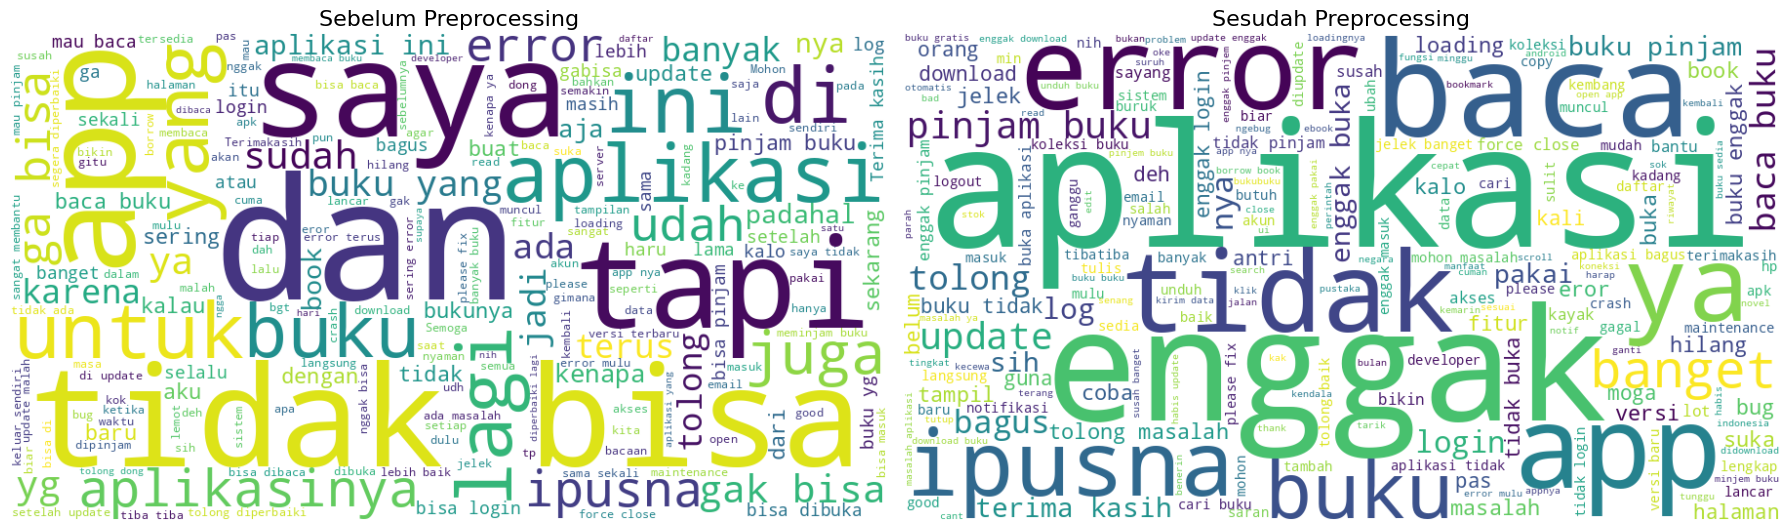

In [ ]:
rawText = " ".join(df["content"].astype(str))

processedText = " ".join(df["final_text"].apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens)))

beforeCloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(rawText)
afterCloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(processedText)

fig, axes = plt.subplots(1, 2, figsize=(18,8))
axes[0].imshow(beforeCloud, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Sebelum Preprocessing", fontsize=16)
axes[1].imshow(afterCloud, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Sesudah Preprocessing", fontsize=16)
plt.tight_layout()
plt.show()

Gambar diatas menunjukkan perbandingan wordcloud sebelum dan sesudah
preprocessing. Sebelum preprocessing, kata yang dominan masih berupa
kata umum seperti "saya", "dan", "tapi". Setelah preprocessing, kata
tidak informatif tersebut tersaring sehingga kata yang lebih relevan
dengan isi ulasan menjadi lebih menonjol, seperti "error", "aplikasi",
"enggak", "buku", dan "pinjam".

#Labeling Data

In [ ]:
# Labeling otomatis pakai model IndoBERT pretrained untuk sentiment analysis
# (menggantikan pendekatan lexicon-based)
!pip install transformers torch -q

from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier",
    tokenizer="w11wo/indonesian-roberta-base-sentiment-classifier",
    device=device
)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/808k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/467k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
# Mapping label output model ke format yang dipakai di pipeline kamu
label_map = {
    "positive": "positive",
    "neutral": "neutral",
    "negative": "negative",
}

def label_with_indobert(text_list, batch_size=32):
    labels, scores = [], []
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i + batch_size]
        batch = [t if str(t).strip() else "unknown" for t in batch]
        results = sentiment_pipeline(batch, truncation=True, max_length=128)
        for r in results:
            labels.append(label_map.get(r["label"].lower(), r["label"].lower()))
            scores.append(r["score"])
    return labels, scores


In [ ]:
texts = df["final_text"].fillna("unknown").tolist()
df["sentimentLabel"], df["sentimentScore"] = label_with_indobert(texts)

print(df["sentimentLabel"].value_counts())

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


sentimentLabel
negative    2043
neutral     1065
positive     405
Name: count, dtype: int64


In [ ]:
df[["final_text", "sentimentScore", "sentimentLabel"]].head()

,final_text,sentimentScore,sentimentLabel
0,warga dana minim baca mohon tingkat aplikasi jujur tidak nyaman baca tidak aplikasi jenis harap ...,0.892397,negative
1,hp android dadak tidak akses ipusnas digilib sedih banget pengin baca gratis legal kendala device,0.993048,negative
2,update baru mei alangkah susah ya baca buku verifikasi perangkat gagal susah negeri sedia rakyat...,0.993878,negative
3,cant even log,0.939375,negative
4,aplikasi jelek awalny ngelag eror enggak minjem enggak buka aplikasi buka aplikasiny data hahaha...,0.996907,negative


#Visualisasi distribusi sentimen

/tmp/ipykernel_507/2443806695.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


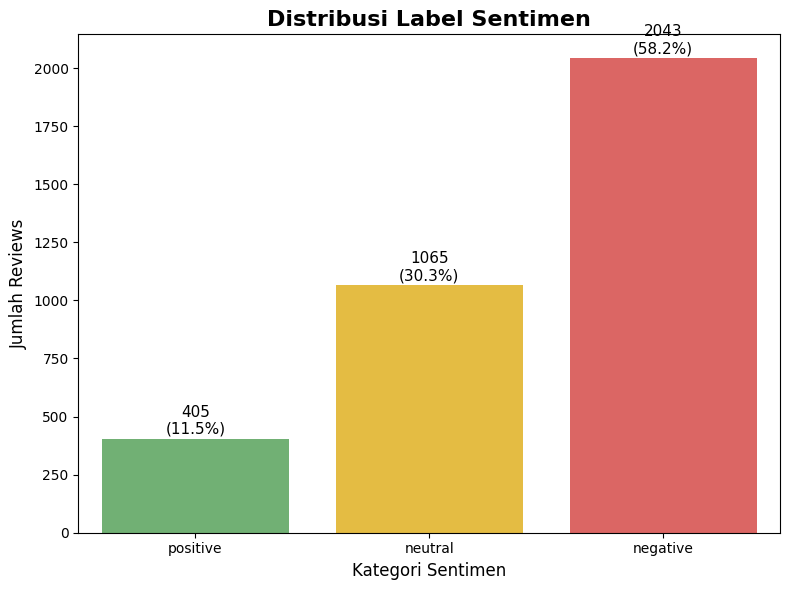

In [ ]:
labelCount = df["sentimentLabel"].value_counts()
labelOrder = ["positive", "neutral", "negative"]
colorPalette = ["#66BB6A", "#FFCA28", "#EF5350"]

plt.figure(figsize=(8,6))
ax = sns.barplot(
    x=labelOrder,
    y=[labelCount.get(label, 0) for label in labelOrder],
    palette=colorPalette
)

totalData = len(df)
for bar in ax.patches:

    count = int(bar.get_height())
    percentage = (count / totalData) * 100

    ax.text(
        bar.get_x() + bar.get_width()/2,
        count + 20,
        f"{count}\n({percentage:.1f}%)",
        ha="center",
        fontsize=11
    )

plt.title("Distribusi Label Sentimen", fontsize=16, fontweight="bold")
plt.xlabel("Kategori Sentimen", fontsize=12)
plt.ylabel("Jumlah Reviews", fontsize=12)
plt.tight_layout()
plt.show()

Grafik diatas menunjukkan distribusi label sentimen pada data awal sebelum
augmentasi, di mana kelas negatif mendominasi dengan 2.043 data (58,2%),
diikuti kelas netral sebanyak 1.065 data (30,3%), dan kelas positif dengan
jumlah paling sedikit yaitu 405 data (11,5%). 

/tmp/ipykernel_507/80319002.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=list(words), y=list(freqs), palette="viridis")


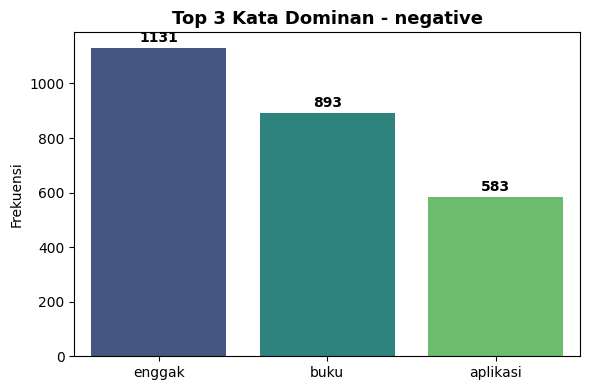

/tmp/ipykernel_507/80319002.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=list(words), y=list(freqs), palette="viridis")


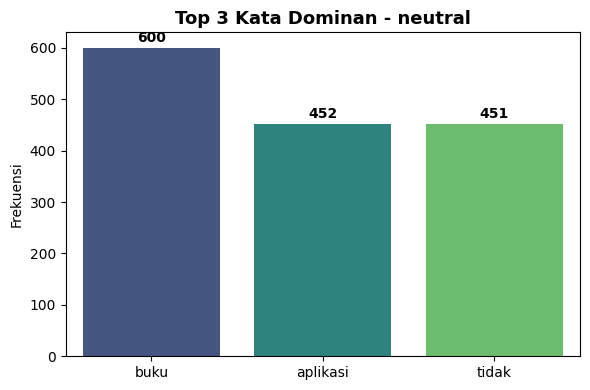

/tmp/ipykernel_507/80319002.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=list(words), y=list(freqs), palette="viridis")


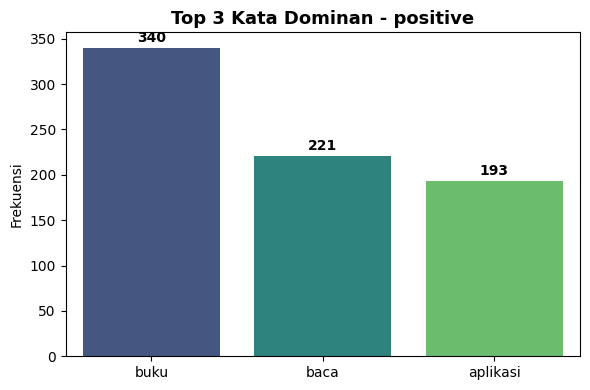

In [ ]:
def plot_top_words(df, label, text_col="final_text", label_col="sentimentLabel", n=3):
    text_gabungan = " ".join(df[df[label_col] == label][text_col].astype(str))
    counter = Counter(text_gabungan.split())
    top = counter.most_common(n)
    words, freqs = zip(*top)

    plt.figure(figsize=(6,4))
    bars = sns.barplot(x=list(words), y=list(freqs), palette="viridis")
    for i, freq in enumerate(freqs):
        plt.text(i, freq + max(freqs)*0.02, str(freq), ha='center', fontweight='bold')
    plt.title(f"Top {n} Kata Dominan - {label}", fontsize=13, fontweight="bold")
    plt.ylabel("Frekuensi")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

for label in df["sentimentLabel"].unique():
    plot_top_words(df, label, n=3)

Grafik diatas menunjukkan tiga kata dengan frekuensi tertinggi pada
masing-masing kelas sentimen. Kata "buku" dan "aplikasi" mendominasi
hampir di semua kelas karena menjadi objek utama ulasan, sedangkan kata
negasi seperti "enggak" dan "tidak" muncul dominan pada kelas negatif
dan netral.

In [ ]:
def top_words_per_class(df, text_col="final_text", label_col="sentimentLabel", n=15):
    for label in df[label_col].unique():
        text_gabungan = " ".join(df[df[label_col] == label][text_col].astype(str))
        kata = text_gabungan.split()
        counter = Counter(kata)
        print(f"\n=== Kata dominan untuk kelas: {label} ===")
        for word, freq in counter.most_common(n):
            print(f"{word}: {freq}")

top_words_per_class(df, n=10)


=== Kata dominan untuk kelas: negative ===
enggak: 1131
buku: 893
aplikasi: 583
baca: 506
tidak: 442
banget: 432
error: 368
pinjam: 339
app: 282
buka: 266

=== Kata dominan untuk kelas: neutral ===
buku: 600
aplikasi: 452
tidak: 451
pinjam: 310
enggak: 263
baca: 222
buka: 202
tolong: 193
login: 187
masalah: 169

=== Kata dominan untuk kelas: positive ===
buku: 340
baca: 221
aplikasi: 193
bagus: 170
enggak: 130
banget: 127
tidak: 75
moga: 75
ipusnas: 74
suka: 73


#Drop dan simpan data bersih

In [ ]:
df = df.drop(columns=['reviewId', 'userName', 'userImage', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion' , 'sentimentScore'])
df.head()

,content,case_folding,cleaning,slang,tokenizing,filtered,stemmed,final_text,sentimentLabel
0,"sebagai warga yang dengan dana minim, tapi ingin tetap membaca, saya mohon sekali, agar ada peni...","sebagai warga yang dengan dana minim, tapi ingin tetap membaca, saya mohon sekali, agar ada peni...",sebagai warga yang dengan dana minim tapi ingin tetap membaca saya mohon sekali agar ada peningk...,sebagai warga yang dengan dana minim tapi ingin tetap membaca saya mohon sekali agar ada peningk...,"[sebagai, warga, yang, dengan, dana, minim, tapi, ingin, tetap, membaca, saya, mohon, sekali, ag...","[warga, dana, minim, membaca, mohon, peningkatan, aplikasi, jujur, tidak, nyaman, baca, tidak, a...","[warga, dana, minim, baca, mohon, tingkat, aplikasi, jujur, tidak, nyaman, baca, tidak, aplikasi...",warga dana minim baca mohon tingkat aplikasi jujur tidak nyaman baca tidak aplikasi jenis harap ...,negative
1,hp saya android 9 mendadak sudah tidak bisa digunakan untuk mengakses ipusnas :( padahal digilib...,hp saya android 9 mendadak sudah tidak bisa digunakan untuk mengakses ipusnas :( padahal digilib...,hp saya android mendadak sudah tidak bisa digunakan untuk mengakses ipusnas padahal digilib lain...,hp saya android mendadak sudah tidak bisa digunakan untuk mengakses ipusnas padahal digilib lain...,"[hp, saya, android, mendadak, sudah, tidak, bisa, digunakan, untuk, mengakses, ipusnas, padahal,...","[hp, android, mendadak, tidak, mengakses, ipusnas, digilib, sedih, banget, pengin, baca, gratis,...","[hp, android, dadak, tidak, akses, ipusnas, digilib, sedih, banget, pengin, baca, gratis, legal,...",hp android dadak tidak akses ipusnas digilib sedih banget pengin baca gratis legal kendala device,negative
2,update terbaru 9 mei 2026 alangkah susahnya ya mau baca buku aja selalu verifikasi perangkat gag...,update terbaru 9 mei 2026 alangkah susahnya ya mau baca buku aja selalu verifikasi perangkat gag...,update terbaru mei alangkah susahnya ya mau baca buku aja selalu verifikasi perangkat gagal susa...,update terbaru mei alangkah susahnya ya mau baca buku saja selalu verifikasi perangkat gagal sus...,"[update, terbaru, mei, alangkah, susahnya, ya, mau, baca, buku, saja, selalu, verifikasi, perang...","[update, terbaru, mei, alangkah, susahnya, ya, baca, buku, verifikasi, perangkat, gagal, susahny...","[update, baru, mei, alangkah, susah, ya, baca, buku, verifikasi, perangkat, gagal, susah, negeri...",update baru mei alangkah susah ya baca buku verifikasi perangkat gagal susah negeri sedia rakyat...,negative
3,Cant even log in,cant even log in,cant even log in,cant even log ini,"[cant, even, log, ini]","[cant, even, log]","[cant, even, log]",cant even log,negative
4,"aplikasinya makin lama makin jelek aja. dari yg awalny sering ngelag, eror gk bisa minjem, gk bi...","aplikasinya makin lama makin jelek aja. dari yg awalny sering ngelag, eror gk bisa minjem, gk bi...",aplikasinya makin lama makin jelek aja dari yg awalny sering ngelag eror gk bisa minjem gk bisa ...,aplikasinya makin lama makin jelek saja dari yang awalny sering ngelag eror enggak bisa minjem e...,"[aplikasinya, makin, lama, makin, jelek, saja, dari, yang, awalny, sering, ngelag, eror, enggak,...","[aplikasinya, jelek, awalny, ngelag, eror, enggak, minjem, enggak, dibuka, aplikasinya, buka, ap...","[aplikasi, jelek, awalny, ngelag, eror, enggak, minjem, enggak, buka, aplikasi, buka, aplikasiny...",aplikasi jelek awalny ngelag eror enggak minjem enggak buka aplikasi buka aplikasiny data hahaha...,negative


In [ ]:
from google.colab import files
df.to_csv('ipusnasdata.csv', index=False)
files.download('ipusnasdata.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
dfdrop = df.drop(columns=['content','case_folding', 'cleaning', 'slang', 'tokenizing', 'filtered', 'stemmed'])
dfdrop.head()

,final_text,sentimentLabel
0,warga dana minim baca mohon tingkat aplikasi jujur tidak nyaman baca tidak aplikasi jenis harap ...,negative
1,hp android dadak tidak akses ipusnas digilib sedih banget pengin baca gratis legal kendala device,negative
2,update baru mei alangkah susah ya baca buku verifikasi perangkat gagal susah negeri sedia rakyat...,negative
3,cant even log,negative
4,aplikasi jelek awalny ngelag eror enggak minjem enggak buka aplikasi buka aplikasiny data hahaha...,negative


In [ ]:
from google.colab import files
dfdrop.to_csv('cleanipusnasdata.csv', index=False)
files.download('cleanipusnasdata.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>